<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/voice_recognition_model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa numpy soundfile matplotlib scikit-learn fastdtw

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.mixture import GaussianMixture
from IPython.display import Javascript, display, Audio
from base64 import b64decode
import subprocess
from pathlib import Path
from google.colab import output, drive

# Mount Google Drive
drive.mount('/content/drive')
GMM_DIR = Path("/content/drive/MyDrive/voice-gmm")
DTW_DIR = Path("/content/drive/MyDrive/voice-dtw")
GMM_DIR.mkdir(exist_ok=True)
DTW_DIR.mkdir(exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp311-cp311-linux_x86_64.whl size=542095 sha256=11c59fbc21761be3ff6982806c80c7c3a6c7562ce5494b8fd0522f3bb44cc8e7
  Stored in directory: /root/.cache/pip/wheels/5c/8a/f6/fd3df9a9714677410a5ccbf3ca519e66db4a54a1c46ea95332
Successfully built fastdtw
Mounted at /content/drive


In [2]:
RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""

def record_audio(sec=3, raw_fn="raw.webm", wav_fn="input.wav"):
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({sec*1000})")
    with open(raw_fn, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    subprocess.run(['ffmpeg', '-y', '-i', raw_fn, '-ar', '16000', '-ac', '1', wav_fn],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return wav_fn


In [9]:
def extract_mfcc(path, n_mfcc=13):
    data, sr = sf.read(path)
    if data.ndim > 1:
        data = np.mean(data, axis=1)
    return librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc).T

def plot_waveform_and_mfcc(path):
    y, sr = librosa.load(path, sr=16000)
    plt.figure(figsize=(10, 3))
    plt.title(f"Waveform of {Path(path).name}")
    librosa.display.waveshow(y, sr=sr)
    plt.tight_layout()
    plt.show()

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time')
    plt.title('MFCC')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    display(Audio(path))

In [3]:
def enroll_user(user_name):
    wav_path = GMM_DIR / f"{user_name}.wav"
    print(f"🎙️ Recording for user: {user_name}")
    record_audio(sec=3, wav_fn=str(wav_path))
    subprocess.run(['cp', str(wav_path), str(DTW_DIR / wav_path.name)])
    print(f"✅ Enrolled {user_name} for both GMM and DTW")
    plot_waveform_and_mfcc(str(wav_path))


In [44]:
from collections import defaultdict

def train_gmm_models():
    print("\n🎯 Training GMM models...")
    grouped_features = defaultdict(list)

    # Group files by base user name (before underscore or full name)
    for wav_file in GMM_DIR.glob("*.wav"):
        base_name = wav_file.stem.split("_")[0]  # "alex_1" → "alex"
        mfcc_feat = extract_mfcc(str(wav_file))
        if mfcc_feat is not None:
            grouped_features[base_name].append(mfcc_feat)

    models = {}
    for user, mfcc_list in grouped_features.items():
        if len(mfcc_list) == 0:
            print(f"⚠️ No valid MFCC features for {user}, skipping...")
            continue

        # Combine all recordings into one training set
        all_features = np.vstack(mfcc_list)
        print(f"📦 Training GMM for {user} with {len(mfcc_list)} recordings...")
        gmm = GaussianMixture(n_components=8, covariance_type='diag', n_init=3)
        gmm.fit(all_features)
        models[user] = gmm

    print(f"\n✅ Finished training {len(models)} GMM model(s).")
    return models


In [59]:
def authenticate_with_fallback(models, gmm_threshold=-150.0, dtw_threshold=350, top_n=5):
    print("\n📥 Recording your test voice...")
    test_path = record_audio(sec=3, wav_fn="test.wav")
    print(f"✅ Recorded test sample: {test_path}")
    plot_waveform_and_mfcc(test_path)
    test_mfcc = extract_mfcc(test_path)

    # ===== GMM COMPARISON =====
    print("\n🔎 GMM Model Comparison:")
    gmm_scores = {}
    for user, model in models.items():
        score = model.score(test_mfcc)
        gmm_scores[user] = score
        status = "✅ Pass" if score >= gmm_threshold else "❌ Fail"
        print(f"📂 {user} — GMM score: {score:.2f} — {status}")

    # Sort GMM matches
    sorted_gmm = sorted(gmm_scores.items(), key=lambda x: x[1], reverse=True)
    best_gmm_user, best_gmm_score = sorted_gmm[0]

    # Show top-N GMM results
    print(f"\n🏆 Top {top_n} GMM Matches:")
    for user, score in sorted_gmm[:top_n]:
        print(f"  {user}: {score:.2f}")

    if best_gmm_score >= gmm_threshold:
        print(f"\n✅ GMM authentication successful: {best_gmm_user}")
        return

    print("\n⚠️ GMM score too low — Trying DTW fallback...")

    # ===== DTW COMPARISON =====
    dtw_results = []
    for file in DTW_DIR.glob("*.wav"):
        user = file.stem.split("_")[0]
        enrolled_mfcc = extract_mfcc(str(file))
        if enrolled_mfcc is None:
            continue
        dist, _ = fastdtw(test_mfcc, enrolled_mfcc, dist=euclidean)
        status = "✅ Pass" if dist <= dtw_threshold else "❌ Fail"
        print(f"📂 {file.name} — DTW distance: {dist:.2f} — {status}")
        dtw_results.append((user, file.name, dist))

    # Sort DTW matches
    sorted_dtw = sorted(dtw_results, key=lambda x: x[2])
    best_dtw_user, best_dtw_file, best_dtw_dist = sorted_dtw[0]

    # Show top-N DTW results
    print(f"\n🏆 Top {top_n} DTW Matches:")
    for user, fname, dist in sorted_dtw[:top_n]:
        print(f"  {user} ({fname}): {dist:.2f}")

    if best_dtw_dist <= dtw_threshold:
        print(f"\n✅ DTW authentication successful: {best_dtw_user} (file: {best_dtw_file}) — Fallback")
    else:
        print("\n❌ Access Denied — No match found")




🎙️ Recording for user: user1


<IPython.core.display.Javascript object>

✅ Enrolled user1 for both GMM and DTW


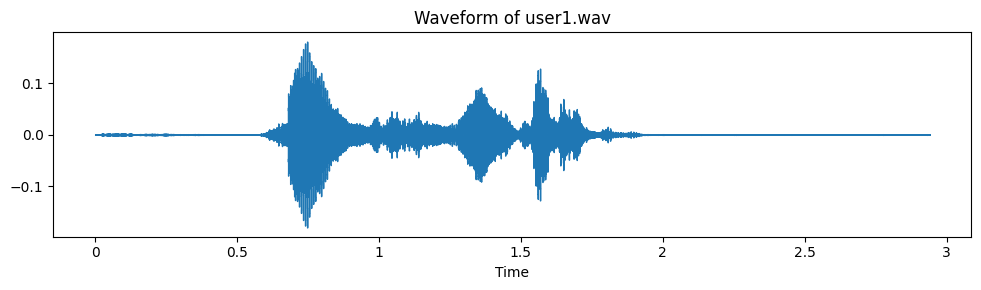

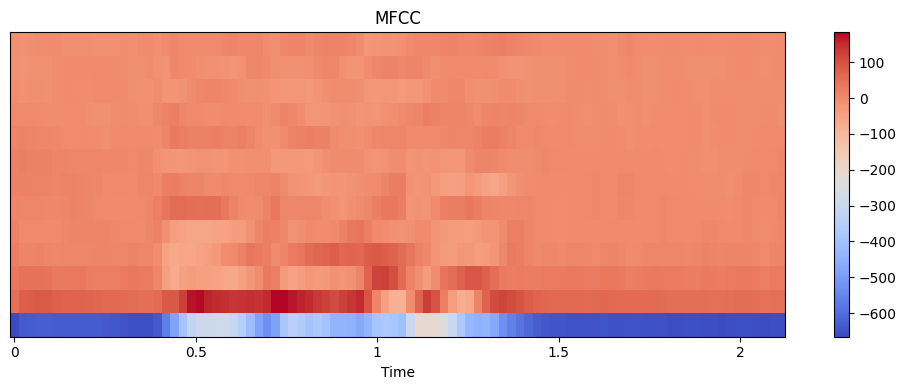

🎙️ Recording for user: user2


<IPython.core.display.Javascript object>

✅ Enrolled user2 for both GMM and DTW


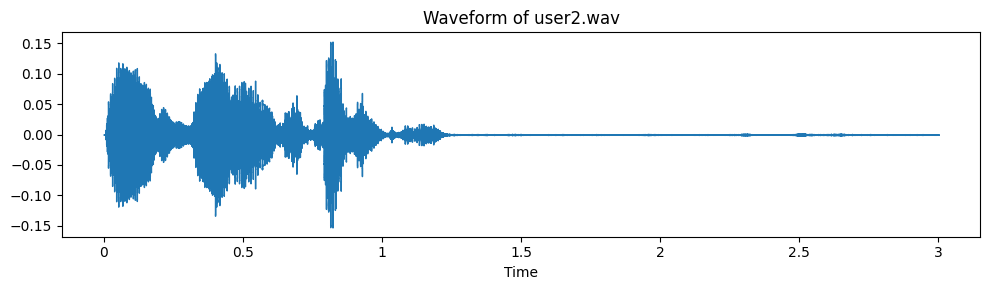

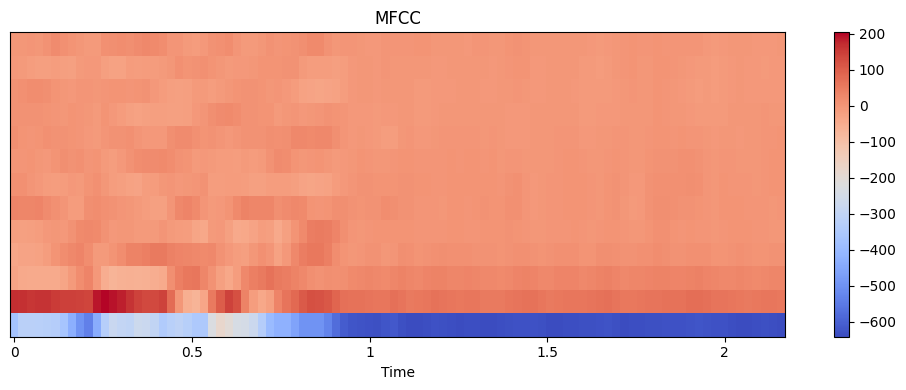

🎙️ Recording for user: user3


<IPython.core.display.Javascript object>

✅ Enrolled user3 for both GMM and DTW


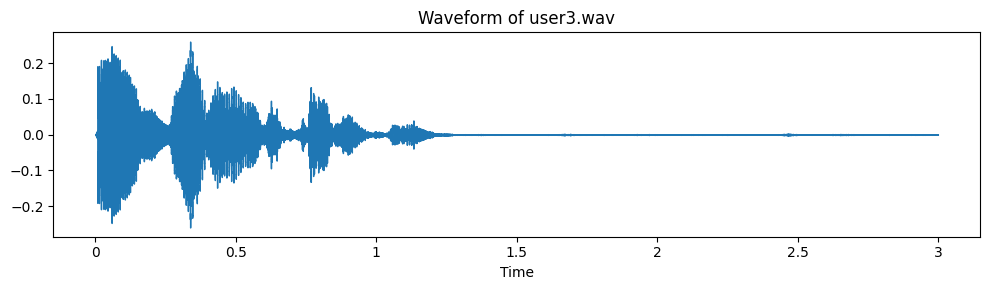

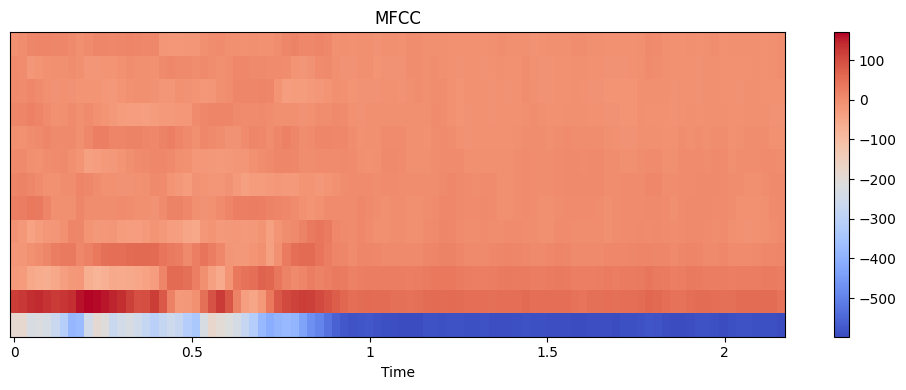

🎙️ Recording for user: user4


<IPython.core.display.Javascript object>

✅ Enrolled user4 for both GMM and DTW


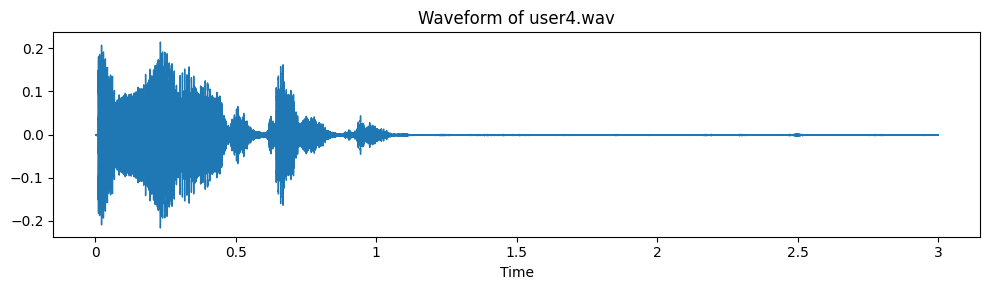

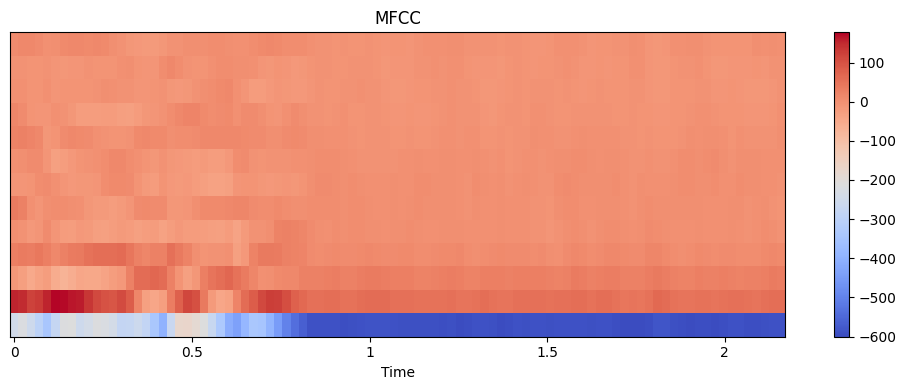

In [18]:
enroll_user("user1")
enroll_user("user2")
enroll_user("user3")
enroll_user("user4")

🎙️ Recording for user: user5


<IPython.core.display.Javascript object>

✅ Enrolled user5 for both GMM and DTW


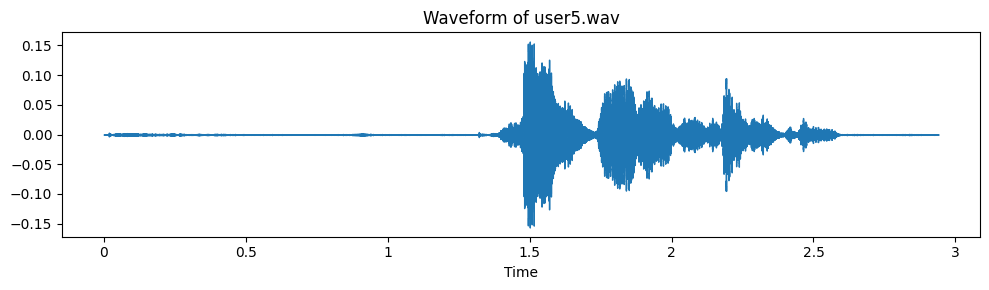

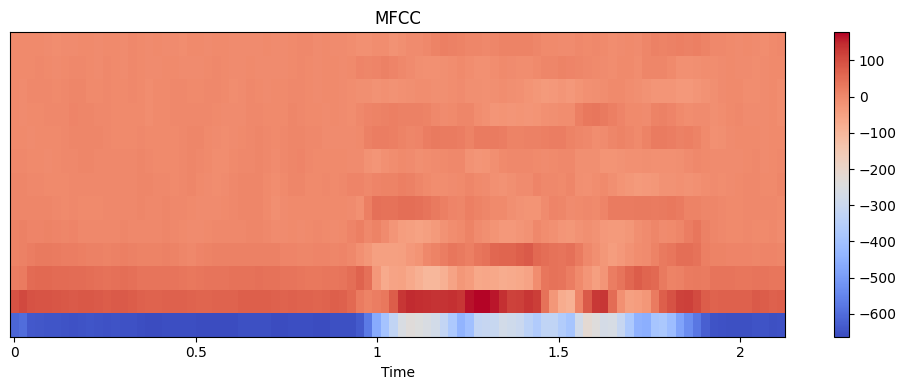

🎙️ Recording for user: user6


<IPython.core.display.Javascript object>

✅ Enrolled user6 for both GMM and DTW


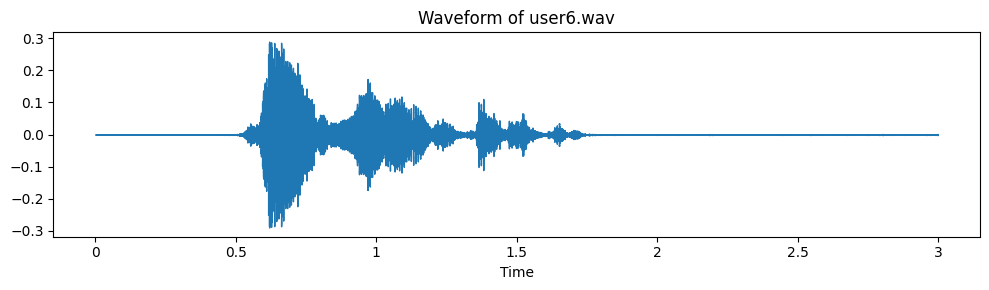

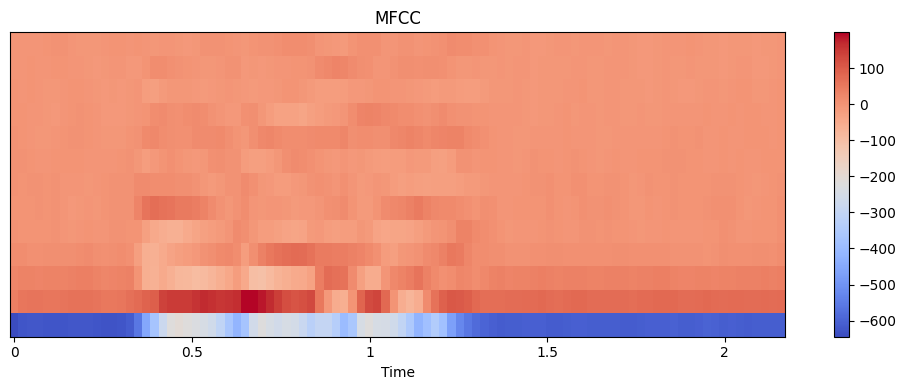

🎙️ Recording for user: user7


<IPython.core.display.Javascript object>

✅ Enrolled user7 for both GMM and DTW


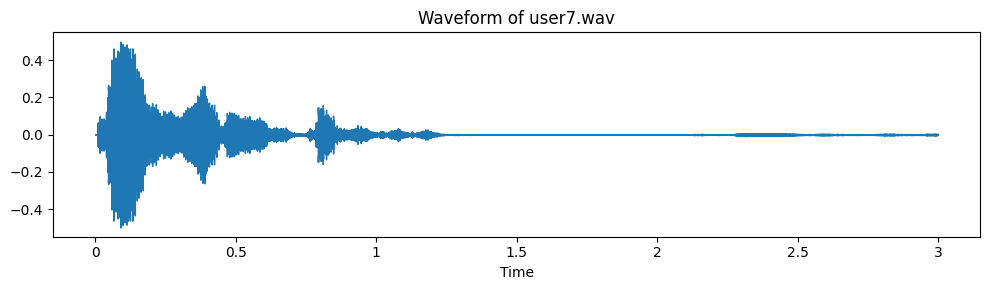

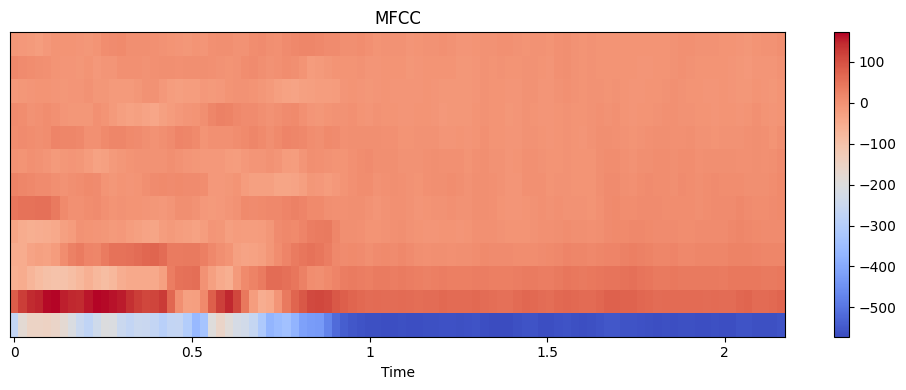

🎙️ Recording for user: user8


<IPython.core.display.Javascript object>

✅ Enrolled user8 for both GMM and DTW


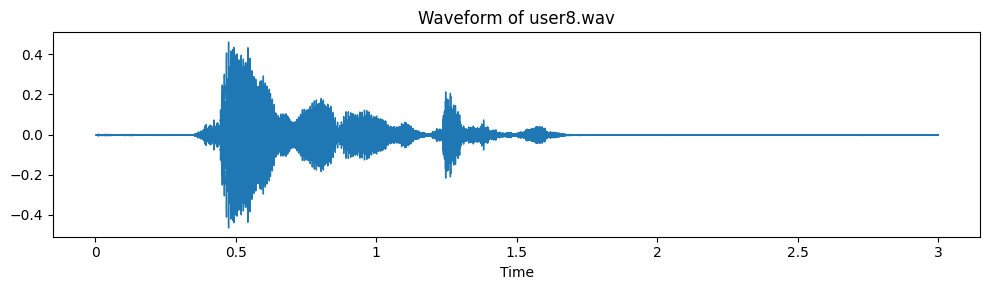

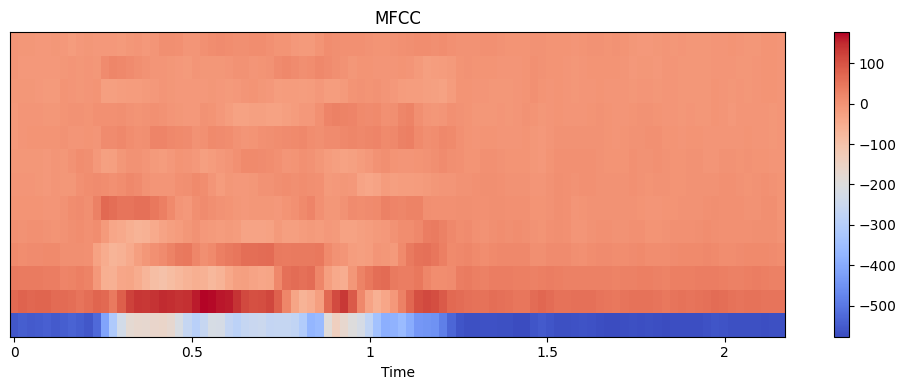

In [19]:
enroll_user("user5")
enroll_user("user6")
enroll_user("user7")
enroll_user("user8")

🎙️ Recording for user: user9


<IPython.core.display.Javascript object>

✅ Enrolled user9 for both GMM and DTW


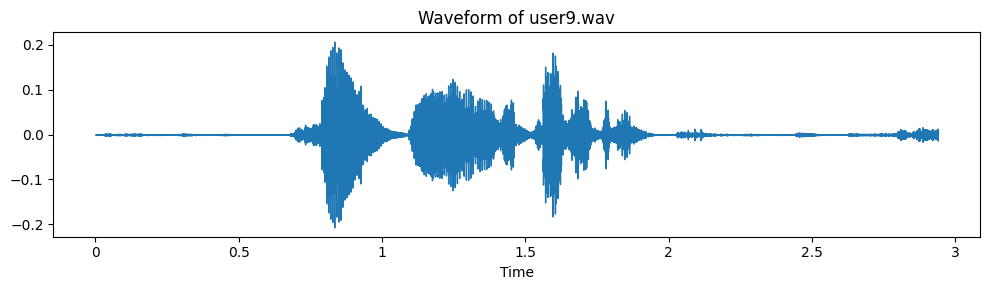

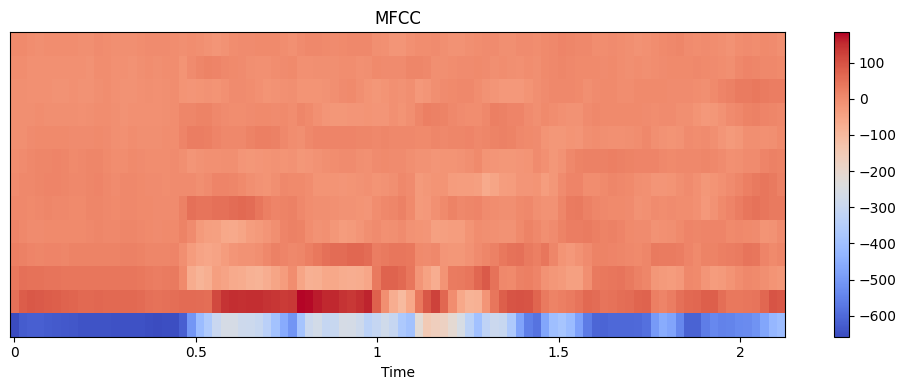

🎙️ Recording for user: user10


<IPython.core.display.Javascript object>

✅ Enrolled user10 for both GMM and DTW


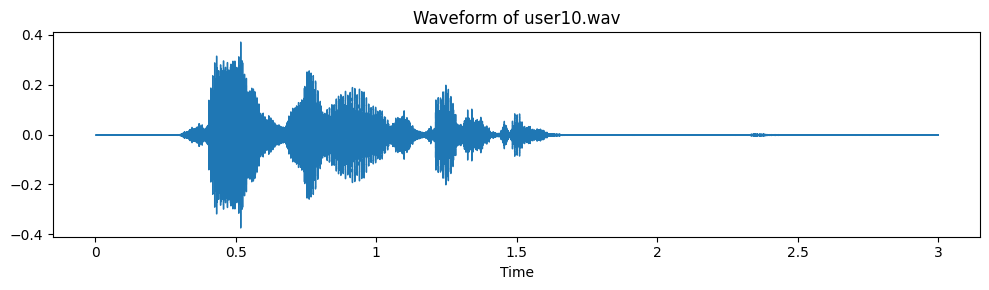

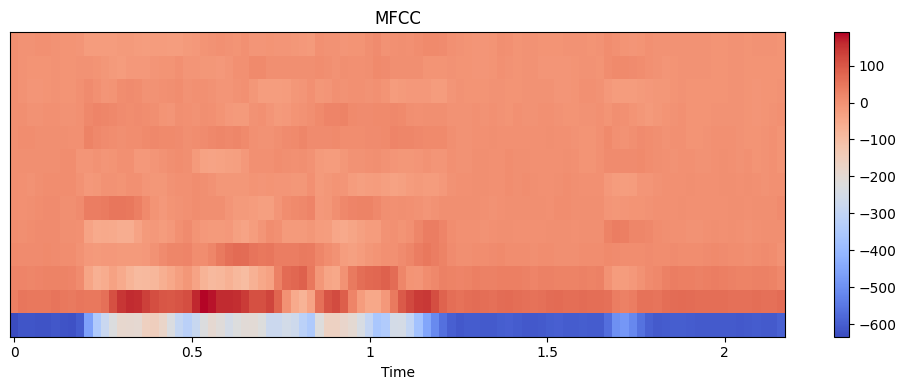

🎙️ Recording for user: user11


<IPython.core.display.Javascript object>

✅ Enrolled user11 for both GMM and DTW


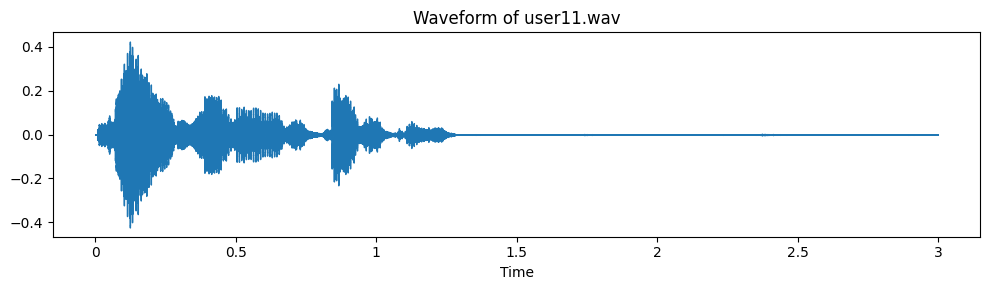

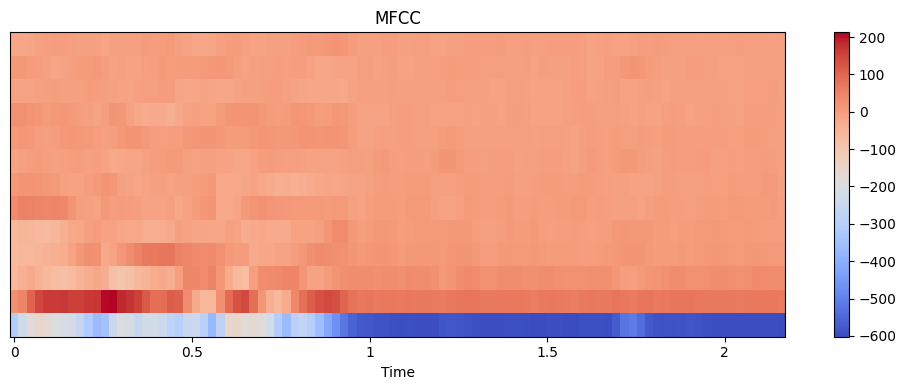

🎙️ Recording for user: user12


<IPython.core.display.Javascript object>

✅ Enrolled user12 for both GMM and DTW


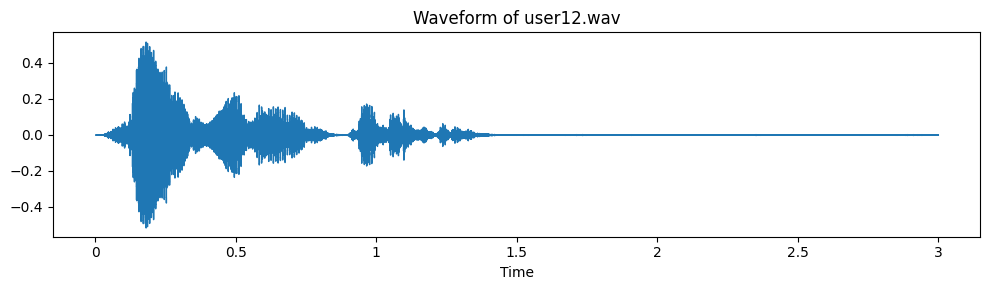

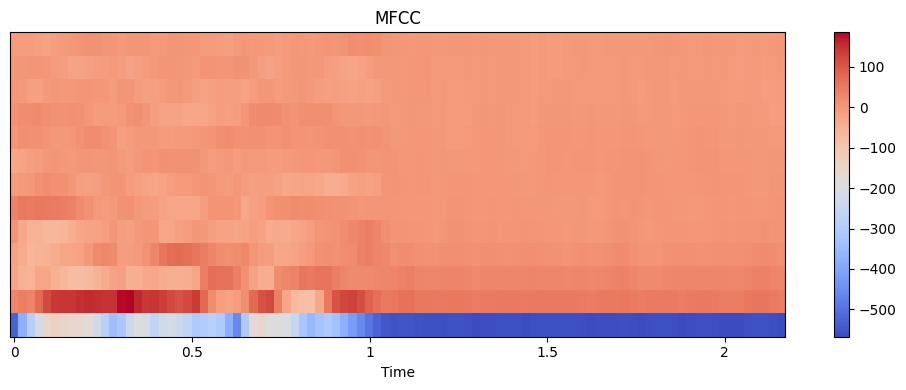

In [20]:
enroll_user("user9")
enroll_user("user10")
enroll_user("user11")
enroll_user("user12")

🎙️ Recording for user: user13


<IPython.core.display.Javascript object>

✅ Enrolled user13 for both GMM and DTW


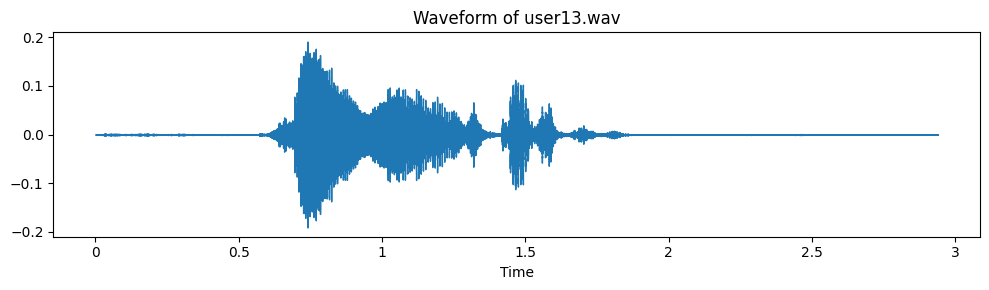

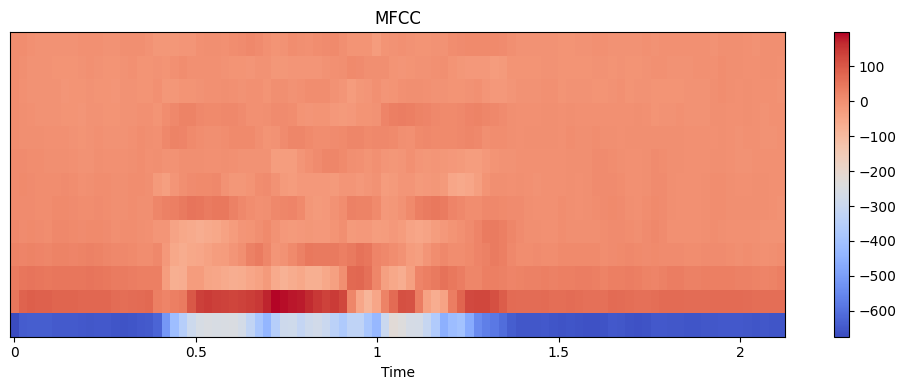

🎙️ Recording for user: user14


<IPython.core.display.Javascript object>

✅ Enrolled user14 for both GMM and DTW


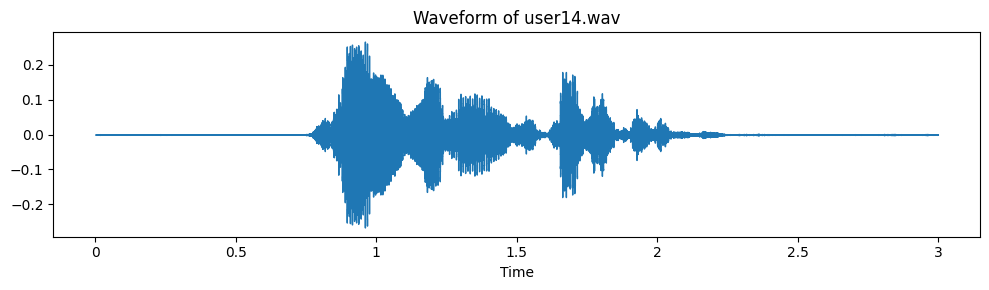

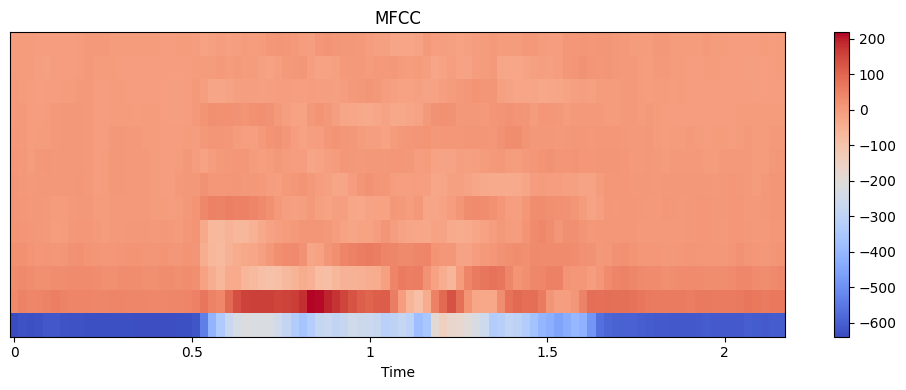

🎙️ Recording for user: user15


<IPython.core.display.Javascript object>

✅ Enrolled user15 for both GMM and DTW


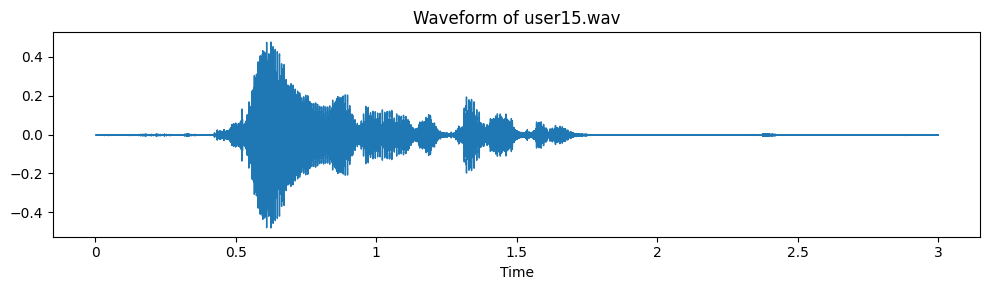

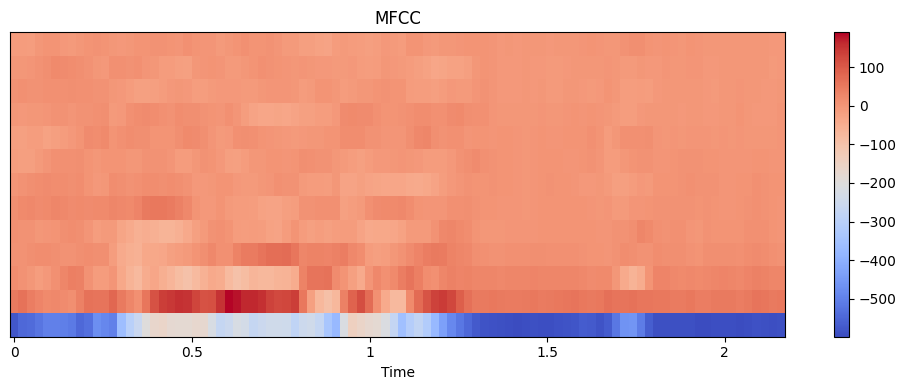

🎙️ Recording for user: user16


<IPython.core.display.Javascript object>

✅ Enrolled user16 for both GMM and DTW


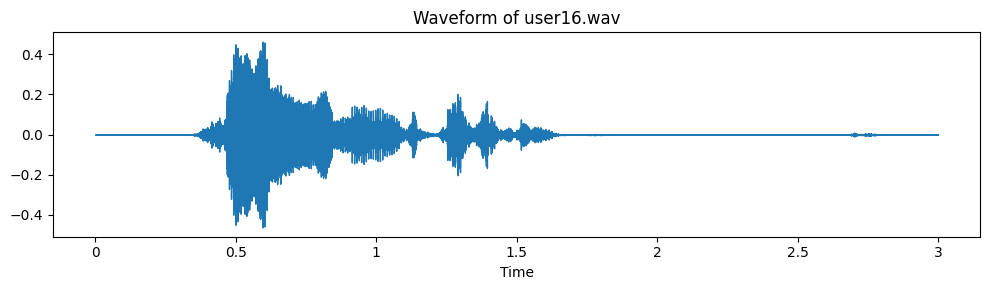

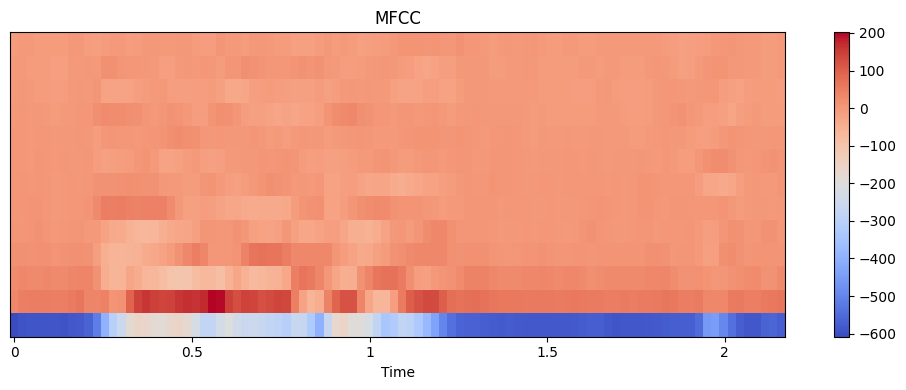

In [21]:
enroll_user("user13")
enroll_user("user14")
enroll_user("user15")
enroll_user("user16")

🎙️ Recording for user: user17


<IPython.core.display.Javascript object>

✅ Enrolled user17 for both GMM and DTW


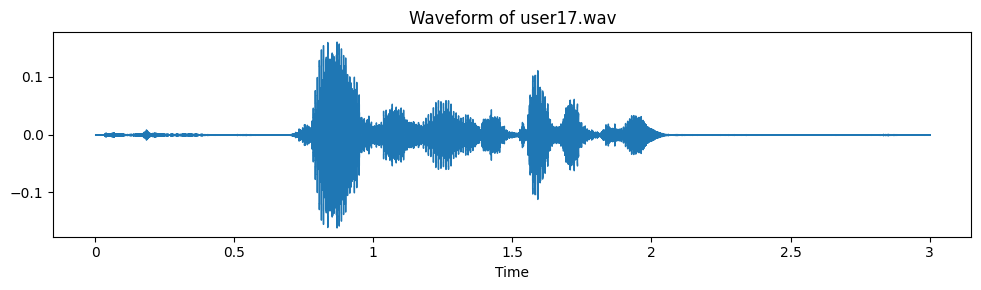

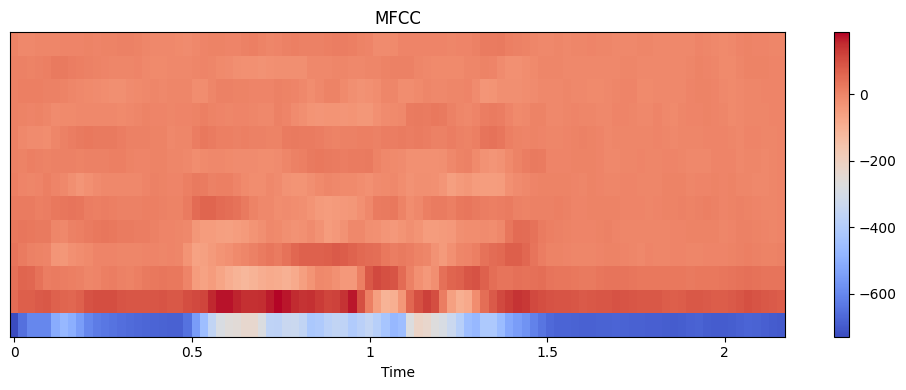

🎙️ Recording for user: user18


<IPython.core.display.Javascript object>

✅ Enrolled user18 for both GMM and DTW


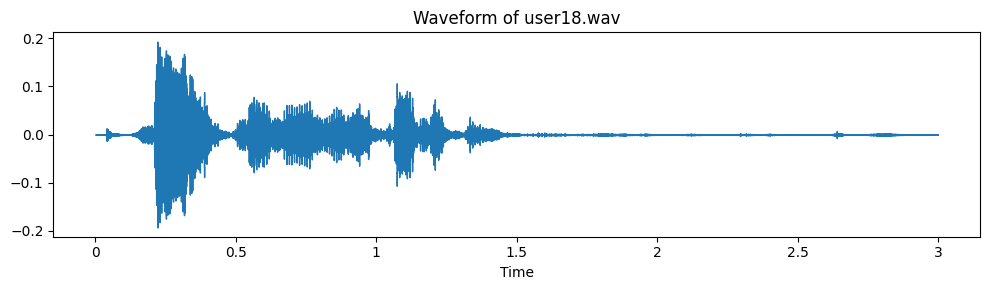

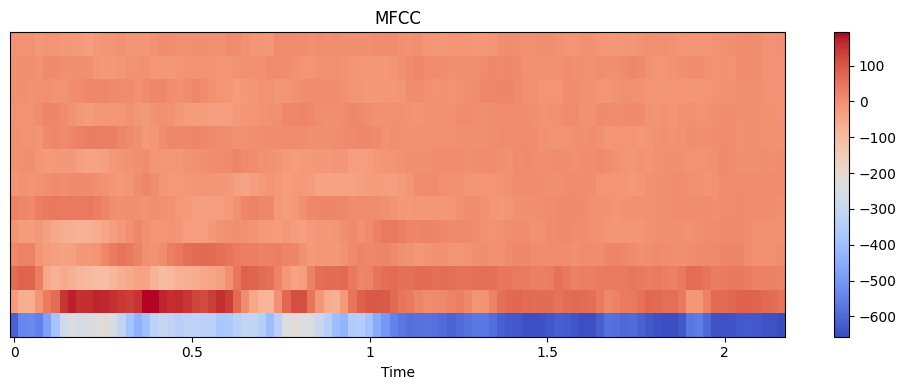

🎙️ Recording for user: user19


<IPython.core.display.Javascript object>

✅ Enrolled user19 for both GMM and DTW


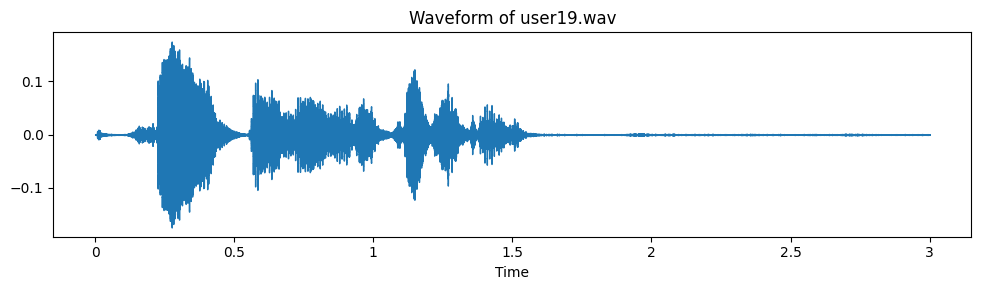

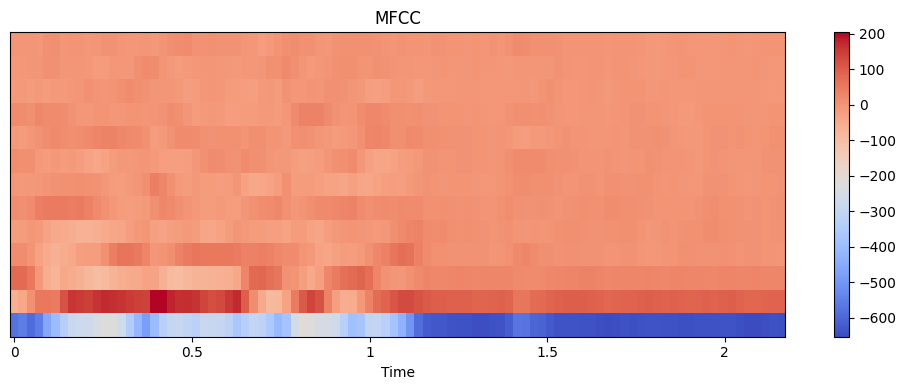

🎙️ Recording for user: user20


<IPython.core.display.Javascript object>

✅ Enrolled user20 for both GMM and DTW


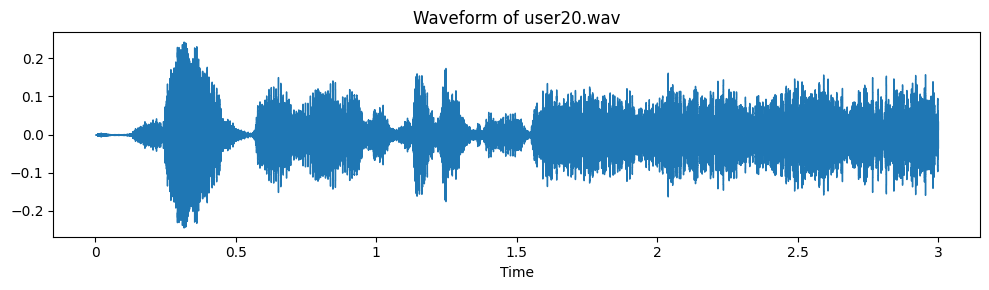

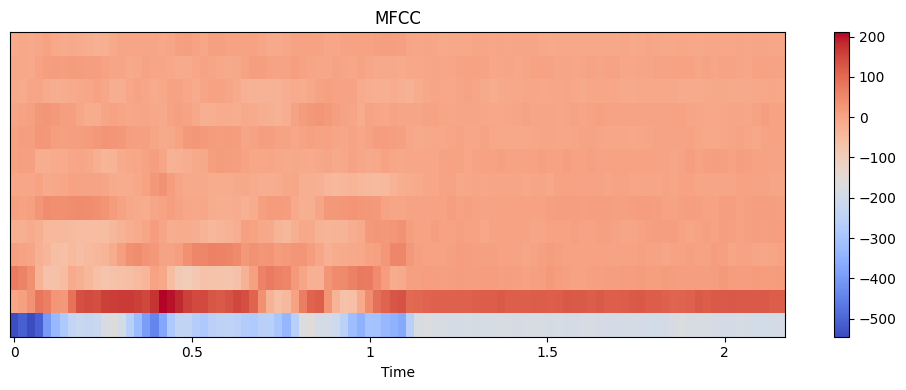

In [22]:
enroll_user("user17")
enroll_user("user18")
enroll_user("user19")
enroll_user("user20")

In [50]:
models = train_gmm_models()


🎯 Training GMM models...
📦 Training GMM for test1 with 1 recordings...
📦 Training GMM for test2 with 1 recordings...
📦 Training GMM for user1 with 1 recordings...
📦 Training GMM for user2 with 1 recordings...
📦 Training GMM for user3 with 1 recordings...
📦 Training GMM for user4 with 1 recordings...
📦 Training GMM for user5 with 1 recordings...
📦 Training GMM for user6 with 1 recordings...
📦 Training GMM for user7 with 1 recordings...
📦 Training GMM for user8 with 1 recordings...
📦 Training GMM for user9 with 1 recordings...
📦 Training GMM for user10 with 1 recordings...
📦 Training GMM for user11 with 1 recordings...
📦 Training GMM for user12 with 1 recordings...
📦 Training GMM for user13 with 1 recordings...
📦 Training GMM for user14 with 1 recordings...
📦 Training GMM for user15 with 1 recordings...
📦 Training GMM for user16 with 1 recordings...
📦 Training GMM for user17 with 1 recordings...
📦 Training GMM for user18 with 1 recordings...
📦 Training GMM for user19 with 1 recordings..


📥 Recording your test voice...


<IPython.core.display.Javascript object>

✅ Recorded test sample: test.wav


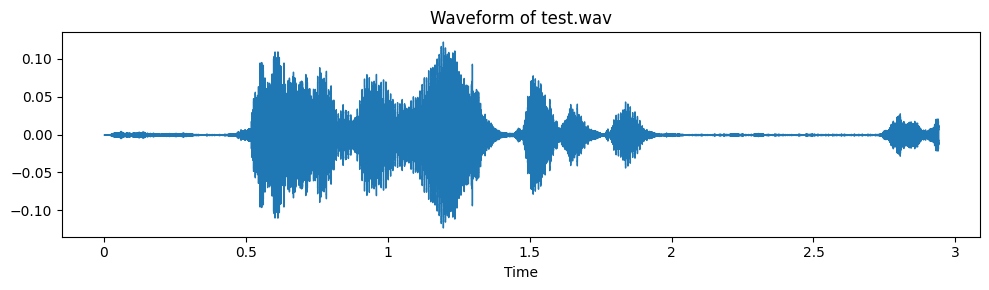

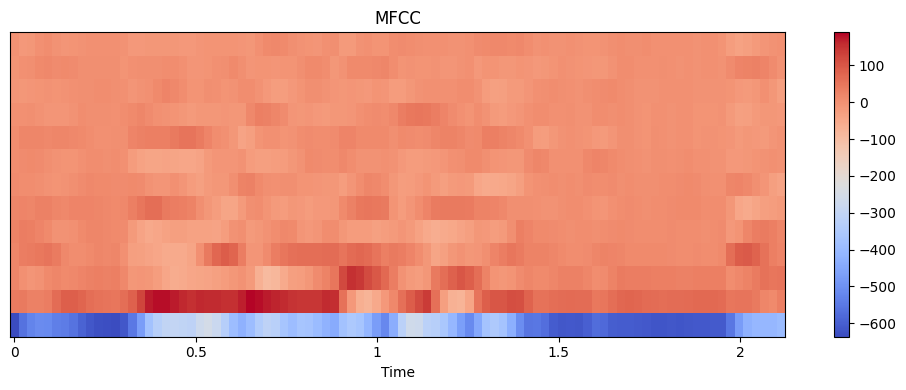


🔎 GMM Model Comparison:
📂 test1 — GMM score: -73.82 — ✅ Pass
📂 test2 — GMM score: -73.44 — ✅ Pass
📂 user1 — GMM score: -68.26 — ✅ Pass
📂 user2 — GMM score: -76.70 — ✅ Pass
📂 user3 — GMM score: -90.14 — ❌ Fail
📂 user4 — GMM score: -98.46 — ❌ Fail
📂 user5 — GMM score: -69.34 — ✅ Pass
📂 user6 — GMM score: -72.81 — ✅ Pass
📂 user7 — GMM score: -84.88 — ❌ Fail
📂 user8 — GMM score: -83.22 — ❌ Fail
📂 user9 — GMM score: -64.93 — ✅ Pass
📂 user10 — GMM score: -76.31 — ✅ Pass
📂 user11 — GMM score: -73.84 — ✅ Pass
📂 user12 — GMM score: -72.64 — ✅ Pass
📂 user13 — GMM score: -80.68 — ❌ Fail
📂 user14 — GMM score: -72.19 — ✅ Pass
📂 user15 — GMM score: -70.95 — ✅ Pass
📂 user16 — GMM score: -71.78 — ✅ Pass
📂 user17 — GMM score: -65.88 — ✅ Pass
📂 user18 — GMM score: -64.13 — ✅ Pass
📂 user19 — GMM score: -64.27 — ✅ Pass
📂 user20 — GMM score: -78.26 — ✅ Pass

🏆 Top 5 GMM Matches:
  user18: -64.13
  user19: -64.27
  user9: -64.93
  user17: -65.88
  user1: -68.26

✅ GMM authentication successful: user18


In [57]:
authenticate_with_fallback(models, gmm_threshold=-80, dtw_threshold=350, top_n=5)
